In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.layers import Input, LSTM, Dense, Attention, Concatenate
from tensorflow.keras.models import Model

In [ ]:
num_samples = 8000
seq_len = 6
vocab_size = 12

X = np.random.randint(1, vocab_size, size=(num_samples, seq_len))
Y = np.flip(X, axis=1)

print("Input Example:", X[0])
print("Target Output:", Y[0])


Input Example: [6 8 5 1 6 4]
Target Output: [4 6 1 5 8 6]


In [ ]:
# ONE-HOT ENCODING
X_onehot = tf.keras.utils.to_categorical(X, num_classes=vocab_size)
Y_onehot = tf.keras.utils.to_categorical(Y, num_classes=vocab_size)

decoder_input_data = np.zeros_like(Y_onehot)
decoder_input_data[:, 1:, :] = Y_onehot[:, :-1, :]

In [ ]:
# BUILD ENCODER
encoder_inputs = Input(shape=(seq_len, vocab_size))

encoder_lstm = LSTM(
    80,
    return_sequences=True,
    return_state=True
)

encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)

In [ ]:
# BUILD DECODER
decoder_inputs = Input(shape=(seq_len, vocab_size))

decoder_lstm = LSTM(
    80,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_inputs,
    initial_state=[state_h, state_c]
)


In [ ]:
# ADD ATTENTION LAYER
attention_layer = Attention()

attention_output = attention_layer([
    decoder_outputs,
    encoder_outputs
])

combined_output = Concatenate(axis=-1)([
    decoder_outputs,
    attention_output
])

In [ ]:
# OUTPUT LAYER
final_outputs = Dense(
    vocab_size,
    activation="softmax"
)(combined_output)

In [ ]:
# CREATE SEQ2SEQ ATTENTION MODEL
model = Model(
    [encoder_inputs, decoder_inputs],
    final_outputs
)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 6, 12)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 6, 12)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 6, 80),   │     29,760 │ input_layer[0][0] │
│                     │ (None, 80),       │            │                   │
│                     │ (None, 80)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 6, 80),   │     29,760 │ input_layer_1[0]… │
│                     │ (None, 80),       │            │ lstm[0][1],       │
│                     │ (None, 80)]       │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 6, 80)     │          0 │ lstm_1[0][0],     │
│ (Attention)         │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 6, 160)    │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 6, 12)     │      1,932 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 61,452 (240.05 KB)

 Trainable params: 61,452 (240.05 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# TRAIN MODEL
history = model.fit(
    [X_onehot, decoder_input_data],
    Y_onehot,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.2472 - loss: 2.3221 - val_accuracy: 0.2951 - val_loss: 2.0016
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3331 - loss: 1.7670 - val_accuracy: 0.3615 - val_loss: 1.5998
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4182 - loss: 1.4657 - val_accuracy: 0.4905 - val_loss: 1.3136
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5938 - loss: 1.1375 - val_accuracy: 0.6893 - val_loss: 0.9646
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7736 - loss: 0.8063 - val_accuracy: 0.8315 - val_loss: 0.6734
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8823 - loss: 0.5599 - val_accuracy: 0.9176 - val_loss: 0.4689
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9403 - loss: 0.3934 - val_accuracy: 0.9511 - val_loss: 0.3424
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9679 - loss: 0.2878 - val_accuracy: 0.9749 - val_

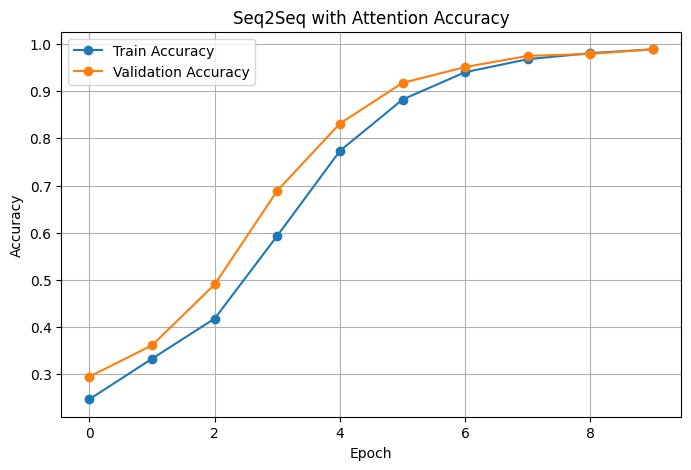

In [ ]:
# PLOT ACCURACY GRAPH
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], marker="o", label="Train Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Seq2Seq with Attention Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

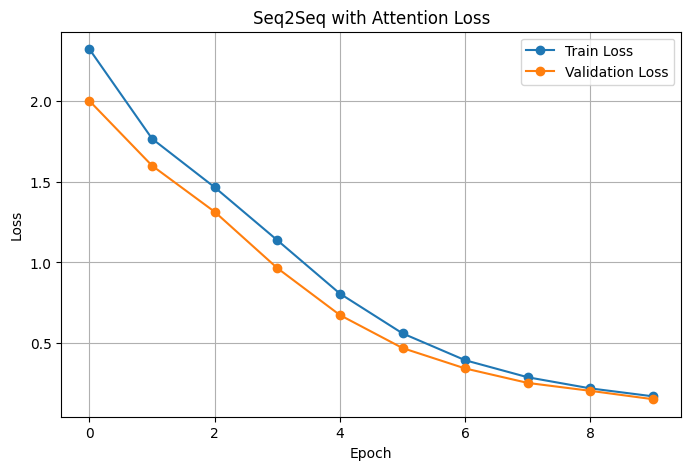

In [ ]:
# PLOT LOSS GRAPH
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], marker="o", label="Train Loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation Loss")
plt.title("Seq2Seq with Attention Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# CREATE ATTENTION SCORE MODEL - FIXED VERSION
class AttentionScoreLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        decoder_output, encoder_output = inputs
        score = tf.matmul(decoder_output, encoder_output, transpose_b=True)
        return tf.nn.softmax(score, axis=-1)

attention_scores = AttentionScoreLayer()([
    decoder_outputs,
    encoder_outputs
])

attention_model = Model(
    [encoder_inputs, decoder_inputs],
    attention_scores
)

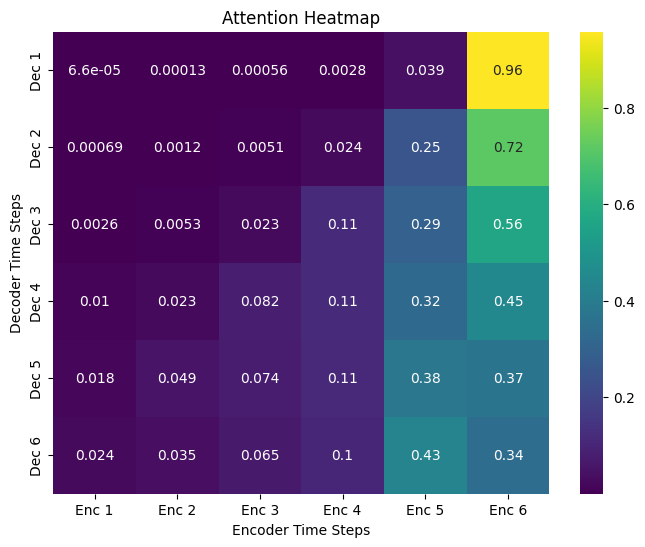

In [ ]:
# VISUALIZE ATTENTION HEATMAP
sample_id = 0

sample_encoder_input = X_onehot[sample_id:sample_id + 1]
sample_decoder_input = decoder_input_data[sample_id:sample_id + 1]

attention_matrix = attention_model.predict(
    [sample_encoder_input, sample_decoder_input],
    verbose=0
)[0]

plt.figure(figsize=(8, 6))

sns.heatmap(
    attention_matrix,
    annot=True,
    cmap="viridis",
    xticklabels=[f"Enc {i+1}" for i in range(seq_len)],
    yticklabels=[f"Dec {i+1}" for i in range(seq_len)]
)

plt.title("Attention Heatmap")
plt.xlabel("Encoder Time Steps")
plt.ylabel("Decoder Time Steps")
plt.show()

In [ ]:
# SAMPLE PREDICTION
prediction = model.predict(
    [sample_encoder_input, sample_decoder_input],
    verbose=0
)

predicted_sequence = np.argmax(
    prediction[0],
    axis=1
)

print("Input Sequence:   ", X[sample_id])
print("Expected Output:  ", Y[sample_id])
print("Predicted Output: ", predicted_sequence)

Input Sequence:    [6 8 5 1 6 4]
Expected Output:   [4 6 1 5 8 6]
Predicted Output:  [4 6 1 5 8 6]
